In [2]:
import sys, os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [3]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from utils.hospital_env import HospitalEnv


In [4]:
data = pd.read_csv("../data/synthetic_hospital_data.csv")
env = HospitalEnv(data)


In [5]:
STATE_DIM = 5
ACTION_DIM = 2

def normalize_state(state):
    arrival, slot, priority, no_show, icu_ratio = state
    return np.array([
        arrival / 480.0,
        slot / 480.0,
        priority / 2.0,
        no_show,
        icu_ratio
    ], dtype=np.float32)



In [6]:
class ReplayBuffer:
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
            np.array(s),
            np.array(a),
            np.array(r),
            np.array(ns),
            np.array(d)
        )

    def __len__(self):
        return len(self.buffer)


In [7]:
class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(STATE_DIM, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, ACTION_DIM)
        )

    def forward(self, x):
        return self.net(x)


In [8]:
policy_net = DQN()
target_net = DQN()

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=0.001)
memory = ReplayBuffer()


In [9]:
episodes = 200
batch_size = 64
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

lr = 1e-3
target_update = 5

Episode 1: Total Reward = -2282.00
Episode 2: Total Reward = -2009.00
Episode 3: Total Reward = -1796.00
Episode 4: Total Reward = -1807.00
Episode 5: Total Reward = -1744.00
Episode 6: Total Reward = -2170.00
Episode 7: Total Reward = -1746.00
Episode 8: Total Reward = -1459.00
Episode 9: Total Reward = -1716.00
Episode 10: Total Reward = -1689.00
Episode 11: Total Reward = -1974.00
Episode 12: Total Reward = -1599.00
Episode 13: Total Reward = -1848.00
Episode 14: Total Reward = -1746.00
Episode 15: Total Reward = -1519.00
Episode 16: Total Reward = -1575.00
Episode 17: Total Reward = -1853.00
Episode 18: Total Reward = -1722.00
Episode 19: Total Reward = -2063.00
Episode 20: Total Reward = -1882.00
Episode 21: Total Reward = -2319.00
Episode 22: Total Reward = -1071.00
Episode 23: Total Reward = -1892.00
Episode 24: Total Reward = -1782.00
Episode 25: Total Reward = -1706.00
Episode 26: Total Reward = -1899.00
Episode 27: Total Reward = -1752.00
Episode 28: Total Reward = -1458.00
E

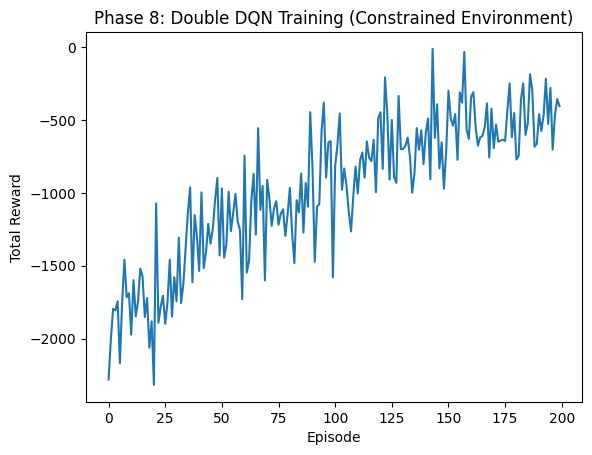

In [10]:
episode_rewards = []

for ep in range(episodes):

    env = HospitalEnv(data)  # Fresh environment per episode
    state = normalize_state(env.reset())
    done = False
    total_reward = 0

    while not done:

        # Epsilon-Greedy Action Selection
        if random.random() < epsilon:
            action = random.randint(0, ACTION_DIM - 1)
        else:
            with torch.no_grad():
                q_vals = policy_net(torch.tensor(state, dtype=torch.float32).unsqueeze(0))
                action = torch.argmax(q_vals,dim=1).item()

        next_state, reward, done = env.step(action)

        if not done:
            next_state_n = normalize_state(next_state)
        else:
            next_state_n = np.zeros(STATE_DIM, dtype=np.float32)

        memory.push(state, action, reward, next_state_n, done)

        state = next_state_n
        total_reward += reward

        # Training Step
        if len(memory) >= batch_size:

            s, a, r, ns, d = memory.sample(batch_size)

            s  = torch.tensor(s, dtype=torch.float32)
            ns = torch.tensor(ns, dtype=torch.float32)
            a  = torch.tensor(a, dtype=torch.long)
            r  = torch.tensor(r, dtype=torch.float32)
            d  = torch.tensor(d, dtype=torch.float32)

            # Q(s, a)
            q_pred = policy_net(s).gather(1, a.unsqueeze(1)).squeeze()

            # -------- Double DQN Target --------
            with torch.no_grad():
                best_actions = torch.argmax(policy_net(ns), dim=1)
                q_next = target_net(ns).gather(1, best_actions.unsqueeze(1)).squeeze()
                q_target = r + gamma * q_next * (1 - d)
            # -----------------------------------

            loss = nn.MSELoss()(q_pred, q_target)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
            optimizer.step()

    # Target Network Update
    if (ep+1) % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Epsilon Decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)
    print(f"Episode {ep+1}: Total Reward = {total_reward:.2f}")

print("\nTraining Completed.")
import os
os.makedirs("models", exist_ok=True)
torch.save(policy_net.state_dict(), "models/ddqn_model.pt")
print("Model saved to models/ddqn_model.pt")

# ==============================
# Plot Learning Curve
# ==============================
plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Phase 8: Double DQN Training (Constrained Environment)")
plt.show()

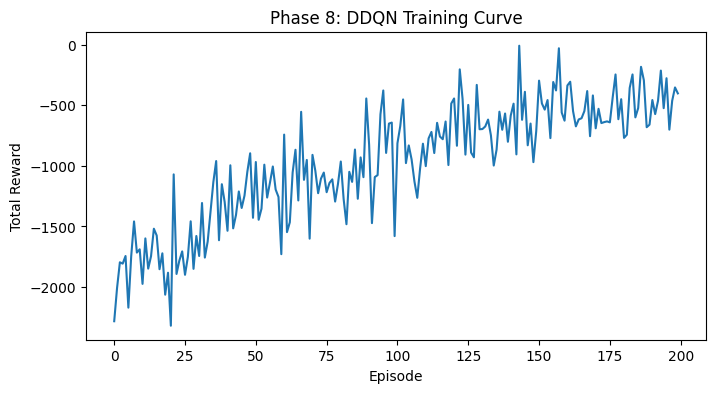

In [11]:
plt.figure(figsize=(8,4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Phase 8: DDQN Training Curve")
plt.show()
